In [14]:
import json
import os
import pandas as pd
from pathlib import Path
from collections import defaultdict

In [15]:

def load_json_files(directory):
    """加载目录下所有JSON文件"""
    json_files = []
    for file_path in Path(directory).glob("*.json"):
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            json_files.append({
                'evaluator': data.get('username', file_path.stem),
                'data': data
            })
    return json_files


def clean_data(evaluator_data):
    """清洗数据：过滤掉维度不足7个或包含全为3分的场景"""
    cleaned_data = {}

    evaluation_results = evaluator_data.get('evaluation_results', {})

    for case_name, case_data in evaluation_results.items():
        cleaned_case_data = {}

        for scene_name, scene_data in case_data.items():
            cleaned_scene_data = {}

            for agent_name, agent_data in scene_data.items():
                dimensions = agent_data.get('dimensions', {})

                # 检查是否有7个维度 且 不全是3分
                if len(dimensions) == 7 and not all(score == 3 for score in dimensions.values()):
                    cleaned_scene_data[agent_name] = {
                        'dimensions': dimensions,
                        'evaluator': evaluator_data.get('username', 'unknown')
                    }

            # 只有当场景中有有效agent时才添加该场景
            if cleaned_scene_data:
                cleaned_case_data[scene_name] = cleaned_scene_data

        # 只有当案例中有有效场景时才添加该案例
        if cleaned_case_data:
            cleaned_data[case_name] = cleaned_case_data

    return cleaned_data


def create_separate_case_tables(json_files):
    """为每个case创建单独的宽表"""
    # 收集所有数据
    all_data = {}

    for file_info in json_files:
        evaluator = file_info['evaluator']
        raw_data = file_info['data']

        cleaned_data = clean_data(raw_data)

        for case_name, case_data in cleaned_data.items():
            if case_name not in all_data:
                all_data[case_name] = {}

            for scene_name, scene_data in case_data.items():
                if scene_name not in all_data[case_name]:
                    all_data[case_name][scene_name] = {}

                for agent_name, agent_info in scene_data.items():
                    if agent_name not in all_data[case_name][scene_name]:
                        all_data[case_name][scene_name][agent_name] = []

                    all_data[case_name][scene_name][agent_name].append({
                        'evaluator': agent_info['evaluator'],
                        'scores_json': json.dumps(agent_info['dimensions'], ensure_ascii=False)
                    })

    # 为每个case创建单独的DataFrame
    case_tables = {}

    for case_name, case_data in all_data.items():
        rows = []

        for scene_name, scene_agents in case_data.items():
            row = {
                'Case': case_name,
                'Scene': scene_name
            }

            # 为每个agent添加评估者和评分JSON
            for agent_name, evaluations in scene_agents.items():
                # 评估者列表
                evaluator_col = f"{agent_name}_Evaluator"
                scores_col = f"{agent_name}_Scores_JSON"

                evaluators = [eval_data['evaluator']
                              for eval_data in evaluations]
                scores = [eval_data['scores_json']
                          for eval_data in evaluations]

                row[evaluator_col] = '|'.join(evaluators)
                row[scores_col] = '|'.join(scores)

            rows.append(row)

        case_tables[case_name] = pd.DataFrame(rows)

    return case_tables


def display_case_tables():
    """显示每个case的表格"""
    # 设置路径
    directory_path = r"d:\Learning\VISeer Lab\UIST26\Tech_eval\backend\evaluators"

    # 加载所有JSON文件
    print("正在加载JSON文件...")
    json_files = load_json_files(directory_path)
    print(f"已加载 {len(json_files)} 个评估者的数据")

    # 创建每个case的表格
    print("正在清洗和处理数据...")
    case_tables = create_separate_case_tables(json_files)

    print(f"共找到 {len(case_tables)} 个不同的案例")

    # 显示每个case的表格
    for case_name, df in case_tables.items():
        print(f"\n{'='*60}")
        print(f"案例: {case_name}")
        print(f"场景数量: {df['Scene'].nunique()}")
        print(f"数据行数: {len(df)}")
        print("="*60)
        print(df)
        print("\n")

        # 保存每个case的表格到Excel的不同工作表
        output_file = "separate_case_evaluation_data.xlsx"
        with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
            for case_name, df in case_tables.items():
                df.to_excel(writer, sheet_name=case_name, index=False)
        print(f"所有案例数据已保存到 {output_file} 的不同工作表中")

    return case_tables


In [16]:
case_tables = display_case_tables()

正在加载JSON文件...
已加载 9 个评估者的数据
正在清洗和处理数据...
共找到 4 个不同的案例

案例: case1
场景数量: 19
数据行数: 19
     Case                            Scene 中等学生_Evaluator  \
0   case1  trigger_question_scene_3_3.json        djh|朱毅超   
1   case1  trigger_question_scene_3_2.json        djh|朱毅超   
2   case1  trigger_question_scene_3_4.json        djh|朱毅超   
3   case1  trigger_question_scene_3_1.json        djh|朱毅超   
4   case1  trigger_question_scene_4_1.json    dlp|dxf|朱海亮   
5   case1  trigger_question_scene_4_2.json        dlp|朱海亮   
6   case1  trigger_question_scene_4_3.json        dlp|朱海亮   
7   case1  trigger_question_scene_2_1.json        dxf|whk   
8   case1  trigger_question_scene_2_2.json        dxf|whk   
9   case1  trigger_question_scene_2_3.json        dxf|whk   
10  case1  trigger_question_scene_2_4.json        dxf|whk   
11  case1  trigger_question_scene_2_5.json        dxf|whk   
12  case1  trigger_question_scene_5_1.json         gaoshh   
13  case1  trigger_question_scene_5_2.json            NaN   
14

In [17]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from collections import defaultdict

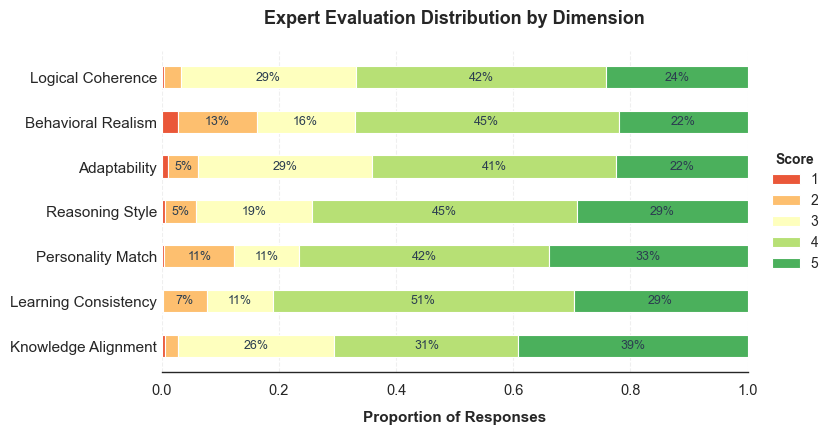

In [34]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import re

# --- 1. 环境配置与科研风格设置 ---
plt.rcParams['font.sans-serif'] = ['Arial',
                                   'Helvetica', 'DejaVu Sans']  # 确保优先使用西文字体
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-white')
sns.set_context("paper", font_scale=1.2)

# 核心映射字典：涵盖了所有可能的中文维度描述
DIMENSION_MAP = {
    '知识水平是否与预设匹配？': 'Knowledge Alignment',
    '学习风格是否保持一致？': 'Learning Consistency',
    '人格特征匹配度（Big Five）': 'Personality Match',
    '推理风格是否符合设置？': 'Reasoning Style',
    '适应一致性表现（可塑性——学习知识的能力）': 'Adaptability',
    '行为频率的合理性（互动真实性）': 'Behavioral Realism',
    '讨论逻辑连贯性（因果链）': 'Logical Coherence',
    # 备选简写（以防万一原始数据中包含这些）
    '属性一致性': 'Attribute Consistency',
    '互动真实性': 'Interaction Realism'
}


def clean_dimension_name(raw_name):
    """
    清洗维度名称：
    1. 去除前缀（如 Agent, 属性一致性-, 互动真实性-）
    2. 匹配映射表转换为英文
    """
    # 去除常见的中文前缀和干扰字符
    clean_name = re.sub(r'^(Agent\s*)?(属性一致性-|互动真实性-)?', '', raw_name).strip()

    # 返回映射后的英文，如果找不到映射，则返回清洗后的原名
    return DIMENSION_MAP.get(clean_name, clean_name)

# --- 2. 数据处理函数 ---


def load_json_files(directory):
    json_files = []
    path = Path(directory)
    if not path.exists():
        return []
    for file_path in path.glob("*.json"):
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            json_files.append({'evaluator': data.get(
                'username', file_path.stem), 'data': data})
    return json_files


def clean_data(evaluator_data):
    """过滤逻辑：确保7个维度且不全是3分"""
    cleaned_data = {}
    evaluation_results = evaluator_data.get('evaluation_results', {})
    for case_name, case_data in evaluation_results.items():
        cleaned_case_data = {}
        for scene_name, scene_data in case_data.items():
            cleaned_scene_data = {}
            for agent_name, agent_data in scene_data.items():
                dimensions = agent_data.get('dimensions', {})
                if len(dimensions) == 7 and not all(score == 3 for score in dimensions.values()):
                    # 在此处直接转换维度 key 为英文
                    eng_dimensions = {clean_dimension_name(
                        k): v for k, v in dimensions.items()}
                    cleaned_scene_data[agent_name] = {
                        'dimensions': eng_dimensions}
            if cleaned_scene_data:
                cleaned_case_data[scene_name] = cleaned_scene_data
        if cleaned_case_data:
            cleaned_data[case_name] = cleaned_case_data
    return cleaned_data


def prepare_plot_data(json_files):
    all_rows = []
    for file_info in json_files:
        cleaned = clean_data(file_info['data'])
        for case, scenes in cleaned.items():
            for scene, agents in scenes.items():
                for agent, info in agents.items():
                    for dim, score in info['dimensions'].items():
                        all_rows.append({'Dimension': dim, 'Score': score})

    df = pd.DataFrame(all_rows)
    # 获取唯一的英文维度列表
    dims = df['Dimension'].unique()

    score_levels = [1, 2, 3, 4, 5]
    plot_data = []
    for dim in dims:
        dim_scores = df[df['Dimension'] == dim]['Score']
        total = len(dim_scores)
        row = [(dim_scores == s).sum() / total for s in score_levels]
        plot_data.append(row)

    return dims, np.array(plot_data)

# --- 3. 绘图主程序 ---


directory_path = r"d:\Learning\VISeer Lab\UIST26\Tech_eval\backend\evaluators"

json_files = load_json_files(directory_path)
if not json_files:
    print("Path error or no files found.")
else:
    dims, proportions = prepare_plot_data(json_files)

    # 创建画布
    fig, ax = plt.subplots(figsize=(8.5, 4.5))

    # UIST 风格调色板 (红-黄-绿)
    colors = sns.color_palette("RdYlGn", 5)

    y_pos = np.arange(len(dims))
    bar_height = 0.5  # 窄 Bar 显得更精致
    left = np.zeros(len(dims))

    # 绘制堆叠条形图
    for i in range(5):
        widths = proportions[:, i]
        ax.barh(y_pos, widths, left=left, height=bar_height,
                label=f"{i+1}", color=colors[i],
                edgecolor='white', linewidth=0.8)

        # 标注百分比
        for j, w in enumerate(widths):
            if w > 0.05:  # 仅显示占比大于 5% 的数字
                ax.text(left[j] + w/2, j, f'{int(w*100)}%',
                        ha='center', va='center',
                        color='#2c3e50', fontsize=9, fontweight='medium')
        left += widths

    # 图表细节精修
    ax.set_yticks(y_pos)
    ax.set_yticklabels(dims, fontsize=11)
    ax.set_xlabel('Proportion of Responses', fontsize=11,
                  fontweight='bold', labelpad=10)
    ax.set_title('Expert Evaluation Distribution by Dimension',
                 fontsize=13, pad=20, fontweight='bold')

    # 移除轴线 (UIST Clean Style)
    sns.despine(left=True, bottom=False, right=True, top=True)
    ax.tick_params(axis='y', length=0)  # 移除 Y 轴刻度小线段

    # 网格线
    ax.set_xlim(0, 1)
    ax.xaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

    # 图例设置 (直接显示分值)
    legend = ax.legend(title='Score',
                       bbox_to_anchor=(1.02, 0.5),
                       loc='center left',
                       frameon=False,
                       title_fontsize=10,
                       fontsize=10)
    legend.get_title().set_weight('bold')

    plt.tight_layout()

    # 如果需要保存为 PDF 投稿
    # plt.savefig('dimension_eval.pdf', bbox_inches='tight', dpi=300)

    plt.show()

e:\anaconda3\envs\IML\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20114 (\N{CJK UNIFIED IDEOGRAPH-4E92}) missing from font(s) Arial.
  fig.canvas.draw()
e:\anaconda3\envs\IML\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) Arial.
  fig.canvas.draw()
e:\anaconda3\envs\IML\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) Arial.
  fig.canvas.draw()
e:\anaconda3\envs\IML\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Arial.
  fig.canvas.draw()
e:\anaconda3\envs\IML\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Arial.
  fig.canvas.draw()
e:\anaconda3\envs\IML\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  fig.canvas.draw(

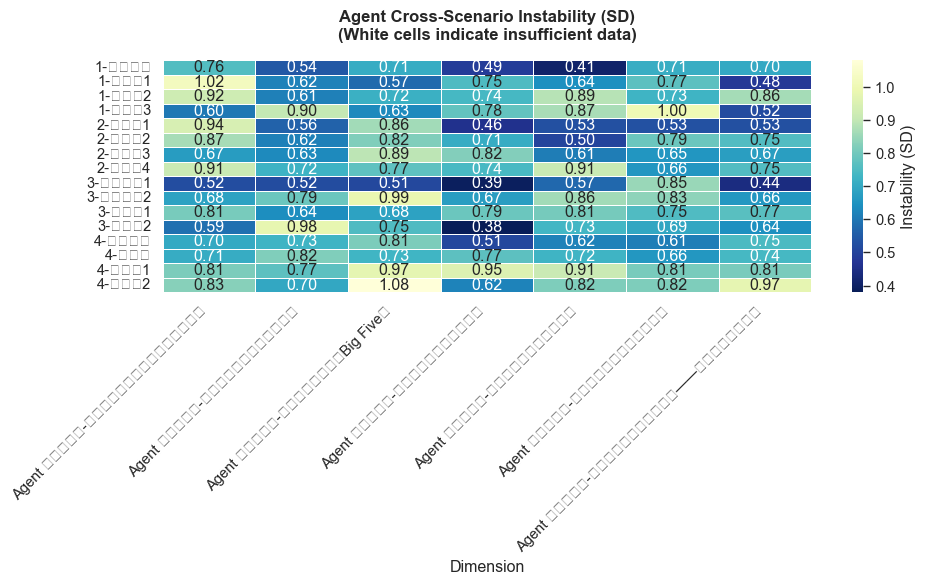

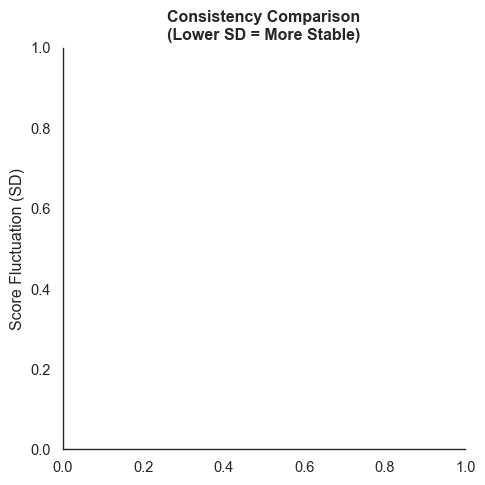


=== Evaluation Statistics ===
                                    count  mean   std
Dimension                                           
Agent 互动真实性-行为频率的合理性（互动真实性）          468  3.70  1.04
Agent 互动真实性-讨论逻辑连贯性（因果链）             468  3.87  0.82
Agent 属性一致性-人格特征匹配度（Big Five）        468  3.98  0.98
Agent 属性一致性-学习风格是否保持一致？              468  4.03  0.85
Agent 属性一致性-推理风格是否符合设置？              468  3.97  0.87
Agent 属性一致性-知识水平是否与预设匹配？             468  4.06  0.89
Agent 属性一致性-适应一致性表现（可塑性——学习知识的能力）    468  3.79  0.88


C:\Users\Zyc-user\AppData\Local\Temp\ipykernel_36400\3666769722.py:151: UserWarning: Glyph 20114 (\N{CJK UNIFIED IDEOGRAPH-4E92}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Zyc-user\AppData\Local\Temp\ipykernel_36400\3666769722.py:151: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Zyc-user\AppData\Local\Temp\ipykernel_36400\3666769722.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Zyc-user\AppData\Local\Temp\ipykernel_36400\3666769722.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Zyc-user\AppData\Local\Temp\ipykernel_36400\3666769722.py:151: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Zyc-user\AppData\Local\Temp\ipykernel_36400\3666769722.py:151: Use

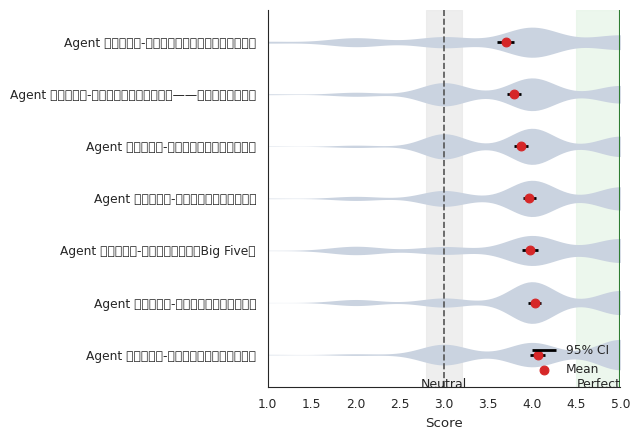

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# ================= 1. 数据加载与清洗模块 =================


def load_and_clean_data(directory_path):
    """从JSON文件直接读取并清洗数据，返回长格式DataFrame"""
    all_rows = []
    path = Path(directory_path)

    for file_path in path.glob("*.json"):
        with open(file_path, 'r', encoding='utf-8') as f:
            raw = json.load(f)
            evaluator = raw.get('username', file_path.stem)
            results = raw.get('evaluation_results', {})

            for case_n, scenes in results.items():
                for scene_n, agents in scenes.items():
                    for agent_n, agent_data in agents.items():
                        dims = agent_data.get('dimensions', {})

                        # 清洗逻辑：维度必须完整且不能全为3分（默认值剔除）
                        if len(dims) >= 7 and not all(v == 3 for v in dims.values()):
                            for dim_name, score in dims.items():
                                all_rows.append({
                                    'Case': case_n,
                                    'Scene': scene_n,
                                    'Agent': agent_n,
                                    'Evaluator': evaluator,
                                    'Dimension': dim_name,
                                    'Score': float(score)
                                })
    return pd.DataFrame(all_rows)


# ================= 2. 专业可视化模块 =================


def plot_vis_style(df, save_path=None):
    if df.empty:
        print("No data available to plot.")
        return

    # =========================
    # 1. 风格（VIS标准）
    # =========================
    sns.set_theme(style="white", context="paper")

    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.linewidth": 0.8
    })

    # =========================
    # 2. 排序
    # =========================
    order = (
        df.groupby("Dimension")["Score"]
        .mean()
        .sort_values()
        .index
    )

    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    # =========================
    # 3. 背景参考区（关键！）
    # =========================
    # Neutral zone (around 3)
    ax.axvspan(2.8, 3.2, color="#EAEAEA", alpha=0.8, zorder=0)
    # High-performance zone
    ax.axvspan(4.5, 5.0, color="#E8F5E9", alpha=0.8, zorder=0)

    # =========================
    # 4. Violin（比box更VIS）
    # =========================
    sns.violinplot(
        data=df,
        y="Dimension",
        x="Score",
        order=order,
        inner=None,
        color="#C7D3E3",
        linewidth=0,
        cut=0,
        ax=ax
    )

    # =========================
    # 5. Mean + 95% CI（核心）
    # =========================
    summary = df.groupby("Dimension")["Score"].agg(
        mean="mean",
        std="std",
        n="count"
    )

    summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["n"])
    summary = summary.loc[order]

    y_pos = np.arange(len(summary))

    # CI线（粗黑线）
    ax.hlines(
        y=y_pos,
        xmin=summary["mean"] - summary["ci95"],
        xmax=summary["mean"] + summary["ci95"],
        color="black",
        linewidth=2,
        zorder=3,
        label="95% CI"
    )

    # Mean点（红色）
    ax.scatter(
        summary["mean"],
        y_pos,
        color="#D62728",
        s=40,
        zorder=4,
        label="Mean"
    )

    # =========================
    # 6. 参考线（强化）
    # =========================
    ax.axvline(3, color="#555555", linestyle="--", linewidth=1.2)
    ax.axvline(5, color="#2E7D32", linestyle="-", linewidth=1.5)

    # 标注（VIS论文常见）
    ax.text(3, len(order)-0.3, "Neutral", ha='center', va='bottom', fontsize=9)
    ax.text(5, len(order)-0.3, "Perfect", ha='right', va='bottom', fontsize=9)

    # =========================
    # 7. 样式精修
    # =========================
    ax.set_xlabel("Score")
    ax.set_ylabel("")
    ax.set_xlim(1, 5)

    sns.despine(left=False, bottom=False)

    ax.legend(frameon=False, loc="lower right")

    plt.tight_layout()

    # =========================
    # 8. 导出
    # =========================
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.savefig(save_path.replace(".png", ".pdf"), bbox_inches="tight")

    plt.show()
# ================= 3. 执行 =================
# 指向你的JSON文件夹
DIR = r"d:\Learning\VISeer Lab\UIST26\Tech_eval\backend\evaluators"
df_main = load_and_clean_data(DIR)

# 打印统计概要（可选）
stats = df_main.groupby('Dimension')['Score'].agg(
    ['count', 'mean', 'std']).round(2)
print("\n=== Evaluation Statistics ===\n", stats)

# 绘图
plot_vis_style(df_main)

In [39]:
import pandas as pd
import json
import numpy as np


def analyze_consistency_per_case(file_path):
    xls = pd.ExcelFile(file_path)
    final_summary = []

    for sheet_name in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet_name)

        # 1. 动态识别该 Sheet 中的 Agent
        agent_names = [col.replace('_Scores_JSON', '')
                       for col in df.columns if col.endswith('_Scores_JSON')]

        for agent in agent_names:
            score_col = f'{agent}_Scores_JSON'

            # 用于存储该 Agent 每一行（场景）的平均分
            scene_scores_list = []

            # 2. 逐行处理场景
            for _, row in df.iterrows():
                raw_json = row[score_col]
                if pd.isna(raw_json) or str(raw_json).strip() == "":
                    continue  # 跳过没有打分的场景

                # 解析多个评价者
                evaluators = str(raw_json).split('|')
                temp_eval_scores = []
                for ev in evaluators:
                    try:
                        temp_eval_scores.append(json.loads(ev))
                    except:
                        continue

                if not temp_eval_scores:
                    continue

                # 对当前场景的所有评价者求平均值
                scene_avg = pd.DataFrame(temp_eval_scores).mean().to_dict()
                scene_scores_list.append(scene_avg)

            if not scene_scores_list:
                continue

            # 3. 计算跨场景的得分矩阵 (Rows: Scenes, Cols: Dimensions)
            agent_perf_df = pd.DataFrame(scene_scores_list)

            # 4. 对 7 个维度分别计算统计指标
            for dim in agent_perf_df.columns:
                dim_scores = agent_perf_df[dim].dropna()
                if len(dim_scores) < 2:
                    continue  # 只有一个场景有分，无法计算一致性

                m = dim_scores.mean()
                sd = dim_scores.std()
                cv = (sd / m) if m != 0 else 0
                r_range = dim_scores.max() - dim_scores.min()

                final_summary.append({
                    'Case_Setting': sheet_name,
                    'Agent': agent,
                    'Dimension': dim,
                    'Mean_Score': round(m, 2),
                    'Std_Dev': round(sd, 3),
                    'CV_Stability': round(cv, 4),  # 越小越稳定
                    'Max_Min_Delta': round(r_range, 2),
                    'Valid_Scene_Count': len(dim_scores)
                })

    return pd.DataFrame(final_summary)


# 执行分析
df_results = analyze_consistency_per_case('separate_case_evaluation_data.xlsx')

# 为了方便你观察，做一个透视表展示 CV 值
pivot_cv = df_results.pivot_table(
    index=['Case_Setting', 'Agent'],
    columns='Dimension',
    values='CV_Stability'
)

print("--- 跨场景变异系数 (CV) 汇总 (越小代表越一致) ---")
print(pivot_cv)

# 导出结果
df_results.to_excel('Agent_Consistency_Full_Report.xlsx', index=False)
pivot_cv.to_excel('Agent_Consistency_Pivot_CV.xlsx')

--- 跨场景变异系数 (CV) 汇总 (越小代表越一致) ---
Dimension           Agent 互动真实性-行为频率的合理性（互动真实性）  Agent 互动真实性-讨论逻辑连贯性（因果链）  \
Case_Setting Agent                                                          
case1        中等学生                        0.1892                    0.1333   
             差学生1                        0.2832                    0.1678   
             差学生2                        0.2721                    0.1559   
             差学生3                        0.1454                    0.2585   
case2        中学生1                        0.3448                    0.1431   
             中学生2                        0.2474                    0.1635   
             中学生3                        0.1869                    0.1749   
             中学生4                        0.2834                    0.1883   
case3        中等学生1                       0.1217                    0.1236   
             中等学生2                       0.1805                    0.2160   
             好学生1                        0

In [40]:
import pandas as pd
import json
import numpy as np
import statsmodels.formula.api as smf
import warnings

# 忽略模型收敛的警告
warnings.filterwarnings("ignore")


def analyze_mixed_effects_consistency(file_path):
    xls = pd.ExcelFile(file_path)
    raw_data_list = []

    print("--- 步骤 1: 正在解析原始打分数据 (保留所有评价者) ---")
    for sheet_name in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        agent_names = [col.replace('_Scores_JSON', '')
                       for col in df.columns if col.endswith('_Scores_JSON')]

        for agent in agent_names:
            score_col = f'{agent}_Scores_JSON'

            for _, row in df.iterrows():
                scene = row['Scene']
                raw_json = row[score_col]
                if pd.isna(raw_json) or str(raw_json).strip() == "":
                    continue

                # 分解评价者
                evaluators = str(raw_json).split('|')
                for eval_id, ev_content in enumerate(evaluators):
                    try:
                        scores_dict = json.loads(ev_content)
                        # 将每个维度的打分展平
                        for dim, score in scores_dict.items():
                            raw_data_list.append({
                                'Case_Setting': sheet_name,
                                'Agent': agent,
                                'Scene': scene,
                                'Evaluator_ID': eval_id,
                                'Dimension': dim,
                                'Score': float(score)
                            })
                    except:
                        continue

    full_df = pd.DataFrame(raw_data_list)

    print("--- 步骤 2: 正在构建混合效应模型进行方差分解 ---")
    lmm_results = []

    # 按 Case, Agent, Dimension 分组建模
    grouped = full_df.groupby(['Case_Setting', 'Agent', 'Dimension'])

    for (case, agent, dim), group_data in grouped:
        # 必须保证有多个场景且分数有变化，否则模型无法拟合
        if len(group_data['Scene'].unique()) < 2 or group_data['Score'].std() == 0:
            lmm_results.append({
                'Case_Setting': case, 'Agent': agent, 'Dimension': dim,
                'Scene_Variance_Ratio': 0.0, 'Inconsistency_Level': 'Very Low'
            })
            continue

        try:
            # 构建混合效应模型
            # 固定效应为 1 (截距)，随机效应为 Scene
            # 这里的逻辑是：看 Scene 作为一个随机因素，解释了多少分数的波动
            model = smf.mixedlm("Score ~ 1", group_data,
                                groups=group_data["Scene"])
            fit = model.fit()

            # 提取方差分量
            var_scene = fit.cov_re.iloc[0, 0]  # 场景间的方差
            var_resid = fit.scale              # 残差 (评价者间的不一致和随机误差)

            total_var = var_scene + var_resid
            svr = var_scene / total_var if total_var > 0 else 0

            lmm_results.append({
                'Case_Setting': case,
                'Agent': agent,
                'Dimension': dim,
                'Scene_Variance_Ratio': round(svr, 4),
                'Mean_Score': round(fit.params['Intercept'], 2)
            })
        except:
            # 如果模型不收敛，记录为 NaN
            lmm_results.append({
                'Case_Setting': case, 'Agent': agent, 'Dimension': dim,
                'Scene_Variance_Ratio': np.nan, 'Mean_Score': group_data['Score'].mean()
            })

    lmm_df = pd.DataFrame(lmm_results)

    # 3. 转换为透视表展示
    pivot_svr = lmm_df.pivot_table(
        index=['Case_Setting', 'Agent'],
        columns='Dimension',
        values='Scene_Variance_Ratio'
    )

    return lmm_df, pivot_svr


# 执行分析
# 注意：这可能需要几分钟时间，因为要为每个维度拟合一个回归模型
lmm_full, pivot_svr = analyze_mixed_effects_consistency(
    'separate_case_evaluation_data.xlsx')

print("\n--- 场景方差占比 (SVR) 汇总表 ---")
print("解读：数值越接近 0 代表跨场景一致性越好；数值越高代表 Agent 表现随场景波动越大。")
print(pivot_svr)

# 保存结果
pivot_svr.to_excel('LMM_Consistency_Analysis.xlsx')

--- 步骤 1: 正在解析原始打分数据 (保留所有评价者) ---
--- 步骤 2: 正在构建混合效应模型进行方差分解 ---

--- 场景方差占比 (SVR) 汇总表 ---
解读：数值越接近 0 代表跨场景一致性越好；数值越高代表 Agent 表现随场景波动越大。
Dimension           Agent 互动真实性-行为频率的合理性（互动真实性）  Agent 互动真实性-讨论逻辑连贯性（因果链）  \
Case_Setting Agent                                                          
case1        中等学生                        0.1110                    0.1104   
             差学生1                        0.1101                    0.0000   
             差学生2                        0.0000                    0.0000   
             差学生3                        0.0000                    0.6706   
case2        中学生1                        0.0445                    0.3087   
             中学生2                        0.2289                    0.0999   
             中学生3                        0.0000                    0.0000   
             中学生4                        0.0000                    0.5553   
case3        中等学生1                       0.0000                    0.1613   
             中等